# 05. Modelado de `Issue` — clasificación jerárquica de consultas

## Objetivo

En la fase anterior se desarrollaron modelos capaces de predecir la variable **`Product`** a partir del texto de la reclamación. En este notebook se aborda un segundo nivel de clasificación: **`Issue`**, que representa el tipo de problema o motivo concreto de la consulta.

La lógica que se quiere aproximar al proyecto **Mail Intelligence** es:

**Texto de la consulta → Product → Issue**

En un escenario empresarial, esto equivaldría aproximadamente a:

**Email → área/producto → motivo de la consulta → priorización/enrutamiento**

### Estrategia

1. Cargar y validar los datos.
2. Analizar la distribución de `Issue`.
3. Estudiar la relación entre `Product` e `Issue`.
4. Medir el efecto de las clases poco representadas.
5. Construir un **baseline global** con TF-IDF + Linear SVM.
6. Construir un **modelo jerárquico**, entrenando un clasificador de `Issue` específico para cada `Product`.
7. Comparar ambas estrategias sobre exactamente el mismo conjunto de test.
8. Analizar errores y clases problemáticas.
9. Guardar el modelo seleccionado.

> **Nota metodológica:** para evaluar únicamente la capacidad de predecir `Issue`, el modelo jerárquico utiliza el `Product` real del conjunto de test. Así se aísla el segundo nivel del error del clasificador de `Product`. La evaluación end-to-end se realizará posteriormente en el pipeline final.

## 1. Importación de librerías

In [24]:
from pathlib import Path
import warnings
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

## 2. Localización automática del proyecto y del dataset

In [25]:
RUTA_MANUAL = None

COL_TEXTO = "Consumer complaint narrative"
COL_PRODUCT = "Product"
COL_ISSUE = "Issue"

def encontrar_raiz_proyecto():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    if (cwd / "notebooks").exists() and (cwd / "data").exists():
        return cwd
    for parent in [cwd] + list(cwd.parents):
        if (parent / "notebooks").exists() and (parent / "data").exists():
            return parent
    return cwd

ROOT = encontrar_raiz_proyecto()
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_RAW = ROOT / "data" / "raw"
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", ROOT)
print("Processed:", DATA_PROCESSED)
print("Raw:", DATA_RAW)

Raíz del proyecto: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria
Processed: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\data\processed
Raw: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\data\raw


In [26]:
def contiene_columnas_requeridas(path):
    requeridas = {COL_TEXTO, COL_PRODUCT, COL_ISSUE}
    try:
        if path.suffix.lower() == ".csv":
            cols = set(pd.read_csv(path, nrows=0).columns)
        elif path.suffix.lower() in {".parquet", ".pq"}:
            cols = set(pd.read_parquet(path).columns)
        else:
            return False
        return requeridas.issubset(cols)
    except Exception:
        return False

def localizar_dataset():
    if RUTA_MANUAL is not None:
        p = Path(RUTA_MANUAL)
        if not p.is_absolute():
            p = (Path.cwd() / p).resolve()
        if not p.exists():
            raise FileNotFoundError(f"No existe la ruta indicada: {p}")
        return p

    candidatos = []
    for carpeta in [DATA_PROCESSED, DATA_RAW]:
        if carpeta.exists():
            candidatos += sorted(carpeta.glob("*.parquet"))
            candidatos += sorted(carpeta.glob("*.csv"))

    validos = [p for p in candidatos if contiene_columnas_requeridas(p)]
    if not validos:
        raise FileNotFoundError(
            "No se encontró ningún CSV/Parquet con las columnas requeridas. "
            "Indica la ruta manualmente en RUTA_MANUAL."
        )

    validos = sorted(validos, key=lambda p: (0 if "processed" in str(p).lower() else 1, -p.stat().st_size))
    return validos[0]

RUTA_DATOS = localizar_dataset()
print("Dataset seleccionado:")
print(RUTA_DATOS)

Dataset seleccionado:
C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\data\raw\complaints.csv


## 3. Carga de los datos

In [27]:
columnas = [COL_TEXTO, COL_PRODUCT, COL_ISSUE]

inicio = time.time()

chunks = []

for chunk in pd.read_csv(
    RUTA_DATOS,
    usecols=columnas,
    chunksize=200_000,
    low_memory=False
):
    chunks.append(chunk)
    print(f"Registros cargados: {sum(len(c) for c in chunks):,}")

df = pd.concat(chunks, ignore_index=True)

print(f"\nTiempo de carga: {(time.time() - inicio):.1f} segundos")
print("Dimensiones:", df.shape)

display(df.head())

Registros cargados: 200,000
Registros cargados: 400,000
Registros cargados: 600,000
Registros cargados: 800,000
Registros cargados: 1,000,000
Registros cargados: 1,200,000
Registros cargados: 1,400,000
Registros cargados: 1,600,000
Registros cargados: 1,800,000
Registros cargados: 2,000,000
Registros cargados: 2,200,000
Registros cargados: 2,400,000
Registros cargados: 2,600,000
Registros cargados: 2,800,000
Registros cargados: 3,000,000
Registros cargados: 3,200,000
Registros cargados: 3,400,000
Registros cargados: 3,600,000
Registros cargados: 3,800,000
Registros cargados: 4,000,000
Registros cargados: 4,200,000
Registros cargados: 4,400,000
Registros cargados: 4,600,000
Registros cargados: 4,800,000
Registros cargados: 5,000,000
Registros cargados: 5,200,000
Registros cargados: 5,400,000
Registros cargados: 5,600,000
Registros cargados: 5,800,000
Registros cargados: 6,000,000
Registros cargados: 6,200,000
Registros cargados: 6,400,000
Registros cargados: 6,600,000
Registros cargados

,Product,Issue,Consumer complaint narrative
0,"Credit reporting, credit repair services, or other personal consumer reports",Incorrect information on your report,On XX/XX/XXXX I sent in a death certificate and SSN card to Scratch Services to inform them of my father in laws pas...
1,Credit reporting or other personal consumer reports,Incorrect information on your report,I have a long time victim of fraud and identity theft with police reports confirmation and confirmation from some or...
2,Credit reporting or other personal consumer reports,Incorrect information on your report,I have a long time victim of fraud and identity theft with police reports confirmation and confirmation from some or...
3,Credit reporting or other personal consumer reports,Incorrect information on your report,NaN
4,Checking or savings account,Managing an account,From XXXX XXXX through XXXX XXXX my checking account went from XXXX to XXXX without my knowledge or consent. Notifie...


## 4. Validación y limpieza mínima

Para mantener coherencia con el modelado de `Product`, no se aplica una limpieza lingüística agresiva. Se eliminan nulos, cadenas vacías y duplicados exactos de texto + `Product` + `Issue`.

In [28]:
print("Nulos antes de limpiar:")
display(df.isna().sum().to_frame("nulos"))

n_inicial = len(df)
df = df.dropna(subset=[COL_TEXTO, COL_PRODUCT, COL_ISSUE]).copy()
for col in [COL_TEXTO, COL_PRODUCT, COL_ISSUE]:
    df[col] = df[col].astype(str).str.strip()

df = df[(df[COL_TEXTO] != "") & (df[COL_PRODUCT] != "") & (df[COL_ISSUE] != "")].copy()
n_antes_dup = len(df)
df = df.drop_duplicates(subset=[COL_TEXTO, COL_PRODUCT, COL_ISSUE]).reset_index(drop=True)

print(f"Registros iniciales: {n_inicial:,}")
print(f"Tras nulos/vacíos: {n_antes_dup:,}")
print(f"Duplicados eliminados: {n_antes_dup - len(df):,}")
print(f"Dataset final: {len(df):,}")

Nulos antes de limpiar:


,nulos
Product,0
Issue,6
Consumer complaint narrative,13185710


Registros iniciales: 17,021,062
Tras nulos/vacíos: 3,835,352
Duplicados eliminados: 1,241,140
Dataset final: 2,594,212


# Parte A — Análisis exploratorio de `Issue`

## 5. Número de clases y distribución

In [6]:
print(f"Número de Product: {df[COL_PRODUCT].nunique()}")
print(f"Número de Issue:   {df[COL_ISSUE].nunique()}")

issue_counts = df[COL_ISSUE].value_counts()
issue_pct = df[COL_ISSUE].value_counts(normalize=True).mul(100)
tabla_issues = pd.DataFrame({"Frecuencia": issue_counts, "Porcentaje": issue_pct.round(2)})
display(tabla_issues.head(30))

Número de Product: 21
Número de Issue:   173


,Frecuencia,Porcentaje
Issue,,
Incorrect information on your report,657303,25.34
Improper use of your report,353405,13.62
Problem with a credit reporting company's investigation into an existing problem,172743,6.66
Attempts to collect debt not owed,155321,5.99
Problem with a company's investigation into an existing problem,153494,5.92
Managing an account,100662,3.88
Written notification about debt,61729,2.38
Trouble during payment process,56242,2.17
Problem with a purchase shown on your statement,54349,2.10


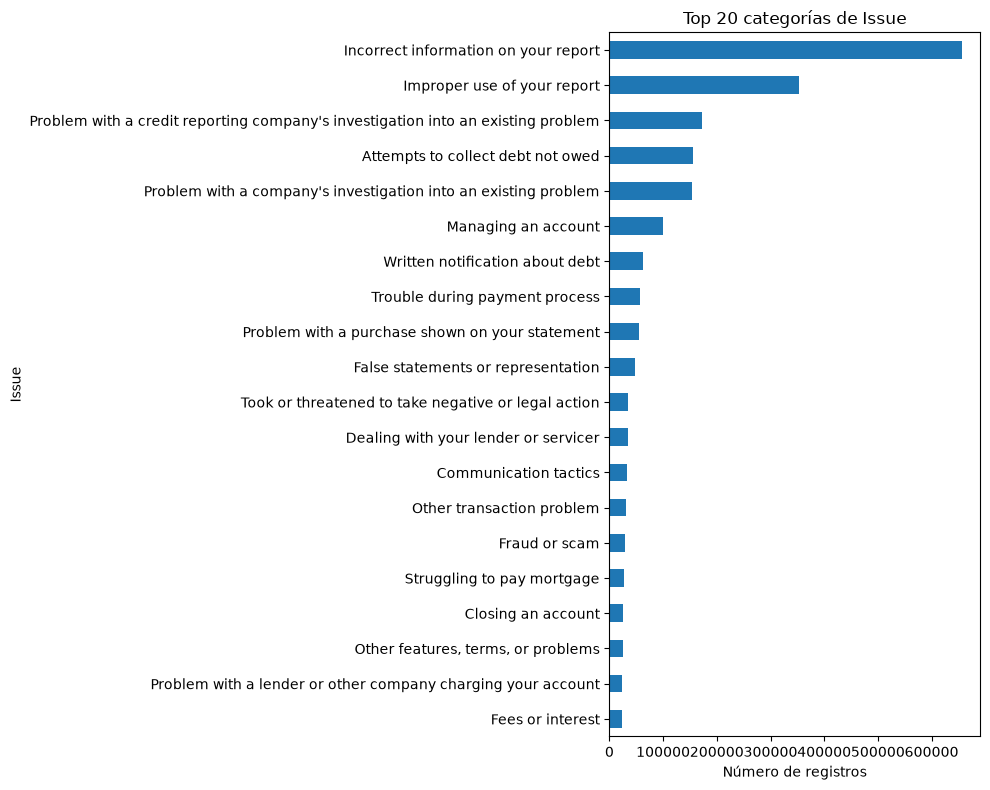

Figura guardada en: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\reports\figures\issue_top20_distribucion.png


In [7]:
top_n = 20
ax = issue_counts.head(top_n).sort_values().plot(kind="barh", figsize=(10, 8), title=f"Top {top_n} categorías de Issue")
ax.set_xlabel("Número de registros")
ax.set_ylabel("Issue")
plt.tight_layout()
ruta_fig = FIGURES_DIR / "issue_top20_distribucion.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_fig)

## 6. Cola de clases minoritarias

Se estudia cuántas clases quedarían por debajo de distintos niveles mínimos de soporte. Esto ayuda a decidir un umbral que permita una evaluación estratificada estable sin perder demasiada cobertura.

In [8]:
umbrales = [2, 5, 10, 20, 50, 100, 500]
resumen_soporte = []
for u in umbrales:
    clases = (issue_counts >= u).sum()
    registros = issue_counts[issue_counts >= u].sum()
    resumen_soporte.append({
        "Mínimo de ejemplos": u,
        "Clases conservadas": clases,
        "Registros conservados": registros,
        "Cobertura (%)": round(registros / len(df) * 100, 2)
    })
display(pd.DataFrame(resumen_soporte))

,Mínimo de ejemplos,Clases conservadas,Registros conservados,Cobertura (%)
0,2,172,2594211,100.00
1,5,169,2594202,100.00
2,10,167,2594186,100.00
3,20,161,2594096,100.00
4,50,154,2593865,99.99
5,100,142,2592921,99.95
6,500,112,2585653,99.67


## 7. Relación entre `Product` e `Issue`

In [9]:
issues_por_producto = df.groupby(COL_PRODUCT)[COL_ISSUE].nunique().sort_values(ascending=False).rename("Número de Issue").to_frame()
registros_por_producto = df[COL_PRODUCT].value_counts().rename("Registros")
tabla_producto_issue = issues_por_producto.join(registros_por_producto).sort_values("Número de Issue", ascending=False)
display(tabla_producto_issue)

,Número de Issue,Registros
Product,,
Credit card,45,117482
"Payday loan, title loan, personal loan, or advance loan",33,18093
"Credit reporting, credit repair services, or other personal consumer reports",30,587929
"Payday loan, title loan, or personal loan",26,17162
Credit card or prepaid card,22,104183
Consumer Loan,18,9429
"Money transfer, virtual currency, or money service",17,96049
Mortgage,16,146014
Student loan,14,62318


In [10]:
productos_por_issue = df.groupby(COL_ISSUE)[COL_PRODUCT].nunique().sort_values(ascending=False)
print("Número medio de Products por Issue:", round(productos_por_issue.mean(), 2))
print("Issues exclusivos de un Product:", (productos_por_issue == 1).sum(), "de", len(productos_por_issue))
print("Issues presentes en más de un Product:", (productos_por_issue > 1).sum())
display(productos_por_issue.head(20).to_frame("Número de Products"))

Número medio de Products por Issue: 1.88
Issues exclusivos de un Product: 101 de 173
Issues presentes en más de un Product: 72


,Número de Products
Issue,
Unable to get your credit report or credit score,10
Problem with fraud alerts or security freezes,10
Improper use of your report,10
Incorrect information on your report,10
Credit monitoring or identity theft protection services,10
Problem with a company's investigation into an existing problem,7
Problem with a credit reporting company's investigation into an existing problem,7
Fraud or scam,6
Problem when making payments,5


## 8. Ajuste del periodo de análisis y alineación con el modelo de Product

El análisis inicial de la relación entre `Product` e `Issue` mostró la presencia de **21 categorías de Product** y **173 categorías de Issue**. Sin embargo, estas categorías corresponden a distintas versiones históricas de la taxonomía del CFPB.

En el modelado previo de `Product` se había seleccionado un periodo temporal más reciente, a partir del **1 de septiembre de 2023**, con el objetivo de trabajar con una taxonomía más homogénea y representativa del esquema actual. En dicho periodo, la variable `Product` queda formada por **11 categorías**.

Para mantener la coherencia entre los dos niveles del sistema de clasificación, se aplica el mismo criterio temporal al modelado de `Issue`:

**Consumer complaint narrative → Product → Issue**

De este modo, el clasificador de `Issue` se desarrolla sobre el mismo universo de productos utilizado previamente para entrenar el clasificador de `Product`.

Además del filtro temporal, se realiza una limpieza específica de las narrativas. Se eliminan los registros sin texto, `Product` o `Issue`, así como las narrativas idénticas asociadas a etiquetas contradictorias. Finalmente, se conserva una única observación por narrativa para evitar que un mismo texto pueda aparecer simultáneamente en entrenamiento y test.

Tras este proceso se obtiene un conjunto final de **1.295.164 narrativas únicas**, correspondientes a **11 categorías de Product** y **89 categorías de Issue**.

A partir de este punto, todos los análisis y modelos de `Issue` se realizan sobre este conjunto de datos depurado.

In [29]:
columnas = [
    "Date received",
    COL_TEXTO,
    COL_PRODUCT,
    COL_ISSUE
]

inicio = time.time()
chunks_filtrados = []
total_leidos = 0
total_filtrados = 0

for chunk in pd.read_csv(
    RUTA_DATOS,
    usecols=columnas,
    chunksize=200_000,
    low_memory=False
):
    # Convertimos la fecha
    chunk["Date received"] = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    # Mismo corte temporal utilizado en Product
    chunk = chunk[
        chunk["Date received"] >= "2023-09-01"
    ].copy()

    total_leidos += 200_000
    total_filtrados += len(chunk)

    chunks_filtrados.append(chunk)

    print(
        f"Procesados: {total_leidos:,} | "
        f"Conservados desde 2023-09-01: {total_filtrados:,}"
    )

df = pd.concat(chunks_filtrados, ignore_index=True)

print("\nCarga y filtrado completados")
print(f"Tiempo: {(time.time() - inicio):.1f} segundos")
print(f"Dimensiones: {df.shape}")

display(df.head())

Procesados: 200,000 | Conservados desde 2023-09-01: 199,972
Procesados: 400,000 | Conservados desde 2023-09-01: 399,972
Procesados: 600,000 | Conservados desde 2023-09-01: 599,972
Procesados: 800,000 | Conservados desde 2023-09-01: 799,972
Procesados: 1,000,000 | Conservados desde 2023-09-01: 999,972
Procesados: 1,200,000 | Conservados desde 2023-09-01: 1,199,972
Procesados: 1,400,000 | Conservados desde 2023-09-01: 1,399,972
Procesados: 1,600,000 | Conservados desde 2023-09-01: 1,599,972
Procesados: 1,800,000 | Conservados desde 2023-09-01: 1,799,972
Procesados: 2,000,000 | Conservados desde 2023-09-01: 1,999,972
Procesados: 2,200,000 | Conservados desde 2023-09-01: 2,199,972
Procesados: 2,400,000 | Conservados desde 2023-09-01: 2,399,972
Procesados: 2,600,000 | Conservados desde 2023-09-01: 2,599,972
Procesados: 2,800,000 | Conservados desde 2023-09-01: 2,799,972
Procesados: 3,000,000 | Conservados desde 2023-09-01: 2,999,972
Procesados: 3,200,000 | Conservados desde 2023-09-01: 3,06

,Date received,Product,Issue,Consumer complaint narrative
0,2023-11-15,Credit reporting or other personal consumer reports,Incorrect information on your report,I have a long time victim of fraud and identity theft with police reports confirmation and confirmation from some or...
1,2023-11-15,Credit reporting or other personal consumer reports,Incorrect information on your report,I have a long time victim of fraud and identity theft with police reports confirmation and confirmation from some or...
2,2023-12-28,Credit reporting or other personal consumer reports,Incorrect information on your report,NaN
3,2024-02-12,Checking or savings account,Managing an account,From XXXX XXXX through XXXX XXXX my checking account went from XXXX to XXXX without my knowledge or consent. Notifie...
4,2025-05-30,Credit reporting or other personal consumer reports,Incorrect information on your report,NaN



Una vez aplicado el filtro temporal, se eliminan los registros que no contienen narrativa, `Product` o `Issue`.

Posteriormente se analiza si una misma narrativa aparece asociada a diferentes etiquetas. Esta comprobación es especialmente importante en un problema de aprendizaje supervisado, ya que un mismo texto asociado a distintas clases introduce una señal contradictoria durante el entrenamiento.

Se estudian por separado:

- narrativas asociadas a más de un `Product`;
- narrativas asociadas a más de un `Issue`.

In [30]:
print("Nulos antes de limpiar:")
display(df.isna().sum().to_frame("nulos"))

# 1. Eliminamos registros sin alguna de las variables necesarias
df_issue = df.dropna(
    subset=[COL_TEXTO, COL_PRODUCT, COL_ISSUE]
).copy()

# 2. Eliminamos espacios
for col in [COL_TEXTO, COL_PRODUCT, COL_ISSUE]:
    df_issue[col] = df_issue[col].astype(str).str.strip()

df_issue = df_issue[
    (df_issue[COL_TEXTO] != "") &
    (df_issue[COL_PRODUCT] != "") &
    (df_issue[COL_ISSUE] != "")
].copy()

print(f"\nTras eliminar nulos/vacíos: {len(df_issue):,}")

# 3. Comprobamos narrativas asociadas a más de un Product
productos_por_texto = (
    df_issue.groupby(COL_TEXTO)[COL_PRODUCT]
    .nunique()
)

textos_ambiguos_product = productos_por_texto[
    productos_por_texto > 1
].index

print(
    "Narrativas asociadas a más de un Product:",
    len(textos_ambiguos_product)
)

# 4. Comprobamos narrativas asociadas a más de un Issue
issues_por_texto = (
    df_issue.groupby(COL_TEXTO)[COL_ISSUE]
    .nunique()
)

textos_ambiguos_issue = issues_por_texto[
    issues_por_texto > 1
].index

print(
    "Narrativas asociadas a más de un Issue:",
    len(textos_ambiguos_issue)
)

# 5. Número de narrativas únicas
print(
    "Narrativas únicas:",
    df_issue[COL_TEXTO].nunique()
)

# 6. Taxonomía en este periodo
print(
    "Número de Product:",
    df_issue[COL_PRODUCT].nunique()
)

print(
    "Número de Issue:",
    df_issue[COL_ISSUE].nunique()
)

Nulos antes de limpiar:


,nulos
Date received,0
Product,0
Issue,6
Consumer complaint narrative,10675269



Tras eliminar nulos/vacíos: 2,307,377
Narrativas asociadas a más de un Product: 1646
Narrativas asociadas a más de un Issue: 5634
Narrativas únicas: 1300999
Número de Product: 11
Número de Issue: 89


Se eliminan las narrativas que presentan etiquetas contradictorias en `Product` o `Issue`. A continuación, se conserva una única observación por narrativa.

Esta decisión evita dos problemas:

1. que exactamente el mismo texto tenga diferentes etiquetas objetivo;
2. que una misma narrativa pueda aparecer simultáneamente en entrenamiento y test, lo que produciría una estimación artificialmente optimista del rendimiento.

Tras esta limpieza se obtiene el conjunto definitivo utilizado para el modelado de `Issue`.

In [31]:
# Narrativas ambiguas en Product o Issue
textos_ambiguos = set(textos_ambiguos_product).union(
    set(textos_ambiguos_issue)
)

print(f"Narrativas ambiguas totales: {len(textos_ambiguos):,}")

# Eliminamos narrativas con etiquetas contradictorias
df_issue_clean = df_issue[
    ~df_issue[COL_TEXTO].isin(textos_ambiguos)
].copy()

print(
    f"Registros tras eliminar narrativas ambiguas: "
    f"{len(df_issue_clean):,}"
)

# Dejamos una única observación por narrativa
df_issue_clean = (
    df_issue_clean
    .drop_duplicates(subset=[COL_TEXTO])
    .reset_index(drop=True)
)

print(f"\nDataset final: {len(df_issue_clean):,}")
print(f"Products: {df_issue_clean[COL_PRODUCT].nunique()}")
print(f"Issues: {df_issue_clean[COL_ISSUE].nunique()}")

display(
    df_issue_clean[
        [COL_TEXTO, COL_PRODUCT, COL_ISSUE]
    ].head()
)

Narrativas ambiguas totales: 5,835
Registros tras eliminar narrativas ambiguas: 1,732,840

Dataset final: 1,295,164
Products: 11
Issues: 89


,Consumer complaint narrative,Product,Issue
0,I have a long time victim of fraud and identity theft with police reports confirmation and confirmation from some or...,Credit reporting or other personal consumer reports,Incorrect information on your report
1,From XXXX XXXX through XXXX XXXX my checking account went from XXXX to XXXX without my knowledge or consent. Notifie...,Checking or savings account,Managing an account
2,"What happened? In XX/XX/year>, XXXX XXXX failed to properly credit deposits and left transactions pending. After I c...","Money transfer, virtual currency, or money service",Other transaction problem
3,"On XXXX, received a Loan Estimate from XXXX XXXX that estimated transfer tax at {$2300.00}. On XXXX, received a clos...",Mortgage,Closing on a mortgage
4,"Subject : Request for Investigation Into Mortgage Balance and Servicing Irregularities To Whom It May Concern, I am ...",Mortgage,Trouble during payment process


## 9. Análisis exploratorio del conjunto definitivo de Issue

Una vez aplicado el mismo periodo temporal utilizado en el modelado de `Product` y eliminadas las narrativas ambiguas y duplicadas, se analiza nuevamente la distribución de la variable objetivo `Issue`.

El conjunto definitivo contiene **1.295.164 narrativas únicas**, correspondientes a **11 categorías de Product** y **89 categorías de Issue**.

Este nuevo análisis permite estudiar el grado de desequilibrio de las clases sobre el conjunto que será utilizado realmente para el entrenamiento de los modelos.

In [32]:
issue_counts = df_issue_clean[COL_ISSUE].value_counts()

issue_pct = (
    df_issue_clean[COL_ISSUE]
    .value_counts(normalize=True)
    .mul(100)
)

tabla_issues = pd.DataFrame({
    "Frecuencia": issue_counts,
    "Porcentaje": issue_pct.round(2)
})

print(f"Número de Products: {df_issue_clean[COL_PRODUCT].nunique()}")
print(f"Número de Issues: {df_issue_clean[COL_ISSUE].nunique()}")
print(f"Número de registros: {len(df_issue_clean):,}")

display(tabla_issues.head(30))

Número de Products: 11
Número de Issues: 89
Número de registros: 1,295,164


,Frecuencia,Porcentaje
Issue,,
Incorrect information on your report,378354,29.21
Improper use of your report,218458,16.87
Problem with a company's investigation into an existing problem,149686,11.56
Attempts to collect debt not owed,74026,5.72
Managing an account,57169,4.41
Written notification about debt,29342,2.27
Problem with a purchase shown on your statement,28066,2.17
Other transaction problem,25264,1.95
False statements or representation,24979,1.93


###  Análisis de las clases minoritarias

La distribución anterior muestra una elevada concentración de observaciones en determinadas categorías. Para estudiar el extremo contrario de la distribución, se analiza cuántas clases y registros se conservarían al exigir distintos niveles mínimos de soporte.

Este análisis permitirá determinar si es necesario establecer un número mínimo de observaciones por categoría antes de realizar la división entre entrenamiento y test.

In [33]:
umbrales = [2, 5, 10, 20, 50, 100, 500]

resumen_soporte = []

for u in umbrales:
    clases = (issue_counts >= u).sum()
    registros = issue_counts[issue_counts >= u].sum()
    cobertura = registros / len(df_issue_clean) * 100

    resumen_soporte.append({
        "Mínimo de ejemplos": u,
        "Clases conservadas": clases,
        "Registros conservados": registros,
        "Cobertura (%)": round(cobertura, 2)
    })

tabla_soporte = pd.DataFrame(resumen_soporte)

display(tabla_soporte)

,Mínimo de ejemplos,Clases conservadas,Registros conservados,Cobertura (%)
0,2,89,1295164,100.00
1,5,88,1295161,100.00
2,10,87,1295154,100.00
3,20,86,1295143,100.00
4,50,82,1294978,99.99
5,100,78,1294678,99.96
6,500,64,1291728,99.73


###  Soporte de las combinaciones Product-Issue

En el enfoque jerárquico, la clasificación de `Issue` se realiza condicionada por el `Product`. Por este motivo, el soporte global de cada categoría `Issue` no es suficiente para determinar si existen datos adecuados para el entrenamiento.

Se analiza también el número de observaciones disponible para cada combinación `Product-Issue`. Esto permite identificar combinaciones poco representadas y determinar un umbral mínimo que permita realizar posteriormente una división estratificada estable entre entrenamiento y test.

In [34]:
# Frecuencia de cada combinación Product-Issue
combinaciones = (
    df_issue_clean
    .groupby([COL_PRODUCT, COL_ISSUE])
    .size()
    .sort_values(ascending=False)
)

print(f"Número total de combinaciones Product-Issue: {len(combinaciones)}")

umbrales_comb = [2, 5, 10, 20, 50, 100, 500]

resumen_combinaciones = []

for u in umbrales_comb:
    combinaciones_conservadas = (combinaciones >= u).sum()
    registros_conservados = combinaciones[combinaciones >= u].sum()
    cobertura = registros_conservados / len(df_issue_clean) * 100

    resumen_combinaciones.append({
        "Mínimo por Product-Issue": u,
        "Combinaciones conservadas": combinaciones_conservadas,
        "Registros conservados": registros_conservados,
        "Cobertura (%)": round(cobertura, 2)
    })

tabla_combinaciones = pd.DataFrame(resumen_combinaciones)

display(tabla_combinaciones)

Número total de combinaciones Product-Issue: 139


,Mínimo por Product-Issue,Combinaciones conservadas,Registros conservados,Cobertura (%)
0,2,135,1295160,100.00
1,5,132,1295153,100.00
2,10,131,1295146,100.00
3,20,128,1295104,100.00
4,50,115,1294635,99.96
5,100,106,1293966,99.91
6,500,80,1288500,99.49


###  Selección del soporte mínimo

El conjunto definitivo contiene **139 combinaciones diferentes de Product-Issue**. El análisis de soporte muestra que algunas combinaciones presentan un número muy reducido de observaciones.

Se establece un mínimo de **20 observaciones por combinación Product-Issue**. Con este criterio se conservan **128 de las 139 combinaciones** y prácticamente el **100 % de los registros disponibles**.

La elección de este umbral busca un equilibrio entre conservar la diversidad de categorías y disponer de un número suficiente de ejemplos para realizar una división estratificada estable entre entrenamiento y test.

Las combinaciones con menos de 20 observaciones se excluyen del modelado. No se agrupan bajo una categoría artificial `Other`, ya que esto introduciría una clase heterogénea formada por problemas conceptualmente diferentes.

In [35]:
# Combinaciones Product-Issue con al menos 20 observaciones
combinaciones_validas = combinaciones[
    combinaciones >= 20
].index

# Filtramos el dataset
indice_combinacion = pd.MultiIndex.from_frame(
    df_issue_clean[[COL_PRODUCT, COL_ISSUE]]
)

df_issue_model = df_issue_clean[
    indice_combinacion.isin(combinaciones_validas)
].copy()

df_issue_model = df_issue_model.reset_index(drop=True)

print(f"Dataset antes del filtro: {len(df_issue_clean):,}")
print(f"Dataset para modelado:    {len(df_issue_model):,}")
print(f"Registros eliminados:     {len(df_issue_clean) - len(df_issue_model):,}")

print(f"\nProducts: {df_issue_model[COL_PRODUCT].nunique()}")
print(f"Issues: {df_issue_model[COL_ISSUE].nunique()}")

n_combinaciones_final = (
    df_issue_model[[COL_PRODUCT, COL_ISSUE]]
    .drop_duplicates()
    .shape[0]
)

print(f"Combinaciones Product-Issue: {n_combinaciones_final}")

Dataset antes del filtro: 1,295,164
Dataset para modelado:    1,295,104
Registros eliminados:     60

Products: 11
Issues: 86
Combinaciones Product-Issue: 128


## 10. Decisión metodológica: clasificación global vs. jerárquica

Una vez definido el conjunto definitivo para el modelado, se comparan dos estrategias para predecir la variable `Issue`.

### Enfoque global

El primer enfoque plantea un único problema multiclase:

**Consumer complaint narrative → Issue**

El modelo recibe únicamente el texto de la reclamación y debe seleccionar directamente una de las **86 categorías de Issue** presentes en el conjunto de modelado.

Este enfoque permite establecer una referencia directa para evaluar la dificultad del problema sin utilizar información adicional sobre `Product`.

### Enfoque jerárquico

El segundo enfoque utiliza la estructura existente entre `Product` e `Issue`:

**Consumer complaint narrative → Product → Issue dentro de Product**

Una vez conocido el `Product`, la predicción de `Issue` se restringe únicamente a las categorías asociadas a dicho producto. De este modo, el modelo no necesita distinguir simultáneamente entre las 86 categorías globales, sino entre un subconjunto más reducido y contextualmente relacionado.

Este planteamiento reproduce además con mayor fidelidad el funcionamiento previsto del sistema final, donde una consulta se clasifica primero por área o producto y posteriormente por el tipo concreto de problema o intención.

### Comparación experimental

Ambos enfoques se evaluarán utilizando el **mismo conjunto de datos y la misma partición de entrenamiento y test**, con el objetivo de que la comparación sea lo más controlada posible.

Debido al fuerte desequilibrio observado entre las categorías de `Issue`, se utilizará **F1 macro como métrica principal**, complementada con accuracy y F1 weighted.

Para garantizar un soporte mínimo adecuado, se conservan únicamente las combinaciones `Product-Issue` con al menos **20 observaciones**. Este criterio mantiene **1.295.104 registros, 86 categorías de Issue y 128 combinaciones Product-Issue**.

In [36]:
#top_por_producto = (
    df.groupby([COL_PRODUCT, COL_ISSUE]).size().rename("Frecuencia").reset_index()
      .sort_values([COL_PRODUCT, "Frecuencia"], ascending=[True, False])
      .groupby(COL_PRODUCT).head(5)
)
display(top_por_producto)

IndentationError: unexpected indent (1311034531.py, line 2)

# Parte B — Preparación del conjunto de modelado

In [37]:
TEST_SIZE = 0.20
df_model = df_issue_model[
    [COL_TEXTO, COL_PRODUCT, COL_ISSUE]
].copy()

df_model["Product_Issue"] = (
    df_model[COL_PRODUCT]
    + " ||| "
    + df_model[COL_ISSUE]
)
print(f"Registros para modelado: {len(df_model):,}")
print(f"Products: {df_model[COL_PRODUCT].nunique()}")
print(f"Issues: {df_model[COL_ISSUE].nunique()}")
print(
    "Combinaciones Product-Issue:",
    df_model["Product_Issue"].nunique()
)

Registros para modelado: 1,295,104
Products: 11
Issues: 86
Combinaciones Product-Issue: 128


## 11. Partición train/test estratificada por Product-Issue

In [38]:
train_df, test_df = train_test_split(
    df_model,
    test_size=TEST_SIZE,
    stratify=df_model["Product_Issue"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (1036083, 4)
Test: (259021, 4)


La partición resultante contiene **1.036.083 observaciones de entrenamiento** y **259.021 observaciones de test**.

Esta partición se mantiene fija durante los experimentos posteriores. Tanto el modelo global como el modelo jerárquico serán entrenados y evaluados sobre las mismas observaciones, evitando que diferencias en la composición de los conjuntos puedan influir en la comparación entre ambos enfoques.

# Parte C — Baseline global

## 12. TF-IDF + Linear SVM — modelo global

Como referencia para la clasificación global de `Issue`, se reutiliza la familia de modelos que obtuvo el mejor comportamiento dentro del enfoque clásico aplicado previamente a `Product`: representación **TF-IDF con unigramas y bigramas** y clasificación mediante **Linear SVM**.

En este experimento, el modelo recibe únicamente la narrativa de la reclamación y debe predecir directamente una de las **86 categorías de Issue**, sin utilizar información sobre `Product`.

###  muestra estratificada de 250k

In [39]:
from sklearn.model_selection import train_test_split

N_TRAIN_GLOBAL = 250_000

train_global, _ = train_test_split(
    train_df,
    train_size=N_TRAIN_GLOBAL,
    stratify=train_df["Product_Issue"],
    random_state=RANDOM_STATE
)

train_global = train_global.reset_index(drop=True)

print(f"Train original: {len(train_df):,}")
print(f"Train utilizado modelo global: {len(train_global):,}")
print(f"Test completo: {len(test_df):,}")

print(f"\nIssues en train global: {train_global[COL_ISSUE].nunique()}")
print(f"Combinaciones Product-Issue: {train_global['Product_Issue'].nunique()}")

Train original: 1,036,083
Train utilizado modelo global: 250,000
Test completo: 259,021

Issues en train global: 86
Combinaciones Product-Issue: 128


In [40]:
tfidf_global = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    dtype=np.float32
)

inicio = time.time()

# El TF-IDF se aprende únicamente con la muestra de entrenamiento
X_train_global = tfidf_global.fit_transform(
    train_global[COL_TEXTO]
)

# El test se mantiene completo
X_test_global = tfidf_global.transform(
    test_df[COL_TEXTO]
)

print("Shape train:", X_train_global.shape)
print("Shape test:", X_test_global.shape)
print(f"Vectorización: {(time.time() - inicio)/60:.2f} min")

Shape train: (250000, 50000)
Shape test: (259021, 50000)
Vectorización: 4.51 min


In [41]:
svm_global = LinearSVC()

inicio = time.time()

# Entrenamiento con la muestra estratificada de 250k
svm_global.fit(
    X_train_global,
    train_global[COL_ISSUE]
)

# Evaluación sobre el test completo
pred_global = svm_global.predict(X_test_global)

a_global = accuracy_score(
    test_df[COL_ISSUE],
    pred_global
)

f1m_global = f1_score(
    test_df[COL_ISSUE],
    pred_global,
    average="macro",
    zero_division=0
)

f1w_global = f1_score(
    test_df[COL_ISSUE],
    pred_global,
    average="weighted",
    zero_division=0
)

print(
    f"Tiempo entrenamiento + predicción: "
    f"{(time.time() - inicio)/60:.2f} min"
)

print(f"Accuracy:    {a_global:.4f}")
print(f"F1 macro:    {f1m_global:.4f}")
print(f"F1 weighted: {f1w_global:.4f}")

Tiempo entrenamiento + predicción: 20.54 min
Accuracy:    0.6160
F1 macro:    0.2785
F1 weighted: 0.6025


## 13. Clases más difíciles del modelo global

In [42]:
report_global = pd.DataFrame(
    classification_report(
        test_df[COL_ISSUE],
        pred_global,
        output_dict=True,
        zero_division=0
    )
).T

display(
    report_global
        .drop(
            index=["accuracy", "macro avg", "weighted avg"],
            errors="ignore"
        )
        .sort_values("f1-score")
        .head(30)
)

,precision,recall,f1-score,support
Advertising,0.000000,0.000000,0.000000,27.0
Can't contact lender or servicer,0.000000,0.000000,0.000000,58.0
Confusing or misleading advertising or marketing,0.000000,0.000000,0.000000,220.0
Credit limit changed,0.000000,0.000000,0.000000,9.0
Identity theft protection or other monitoring services,0.000000,0.000000,0.000000,117.0
Issue where my lender is my school,0.000000,0.000000,0.000000,23.0
Issues with repayment,0.000000,0.000000,0.000000,35.0
Issue with income share agreement,0.000000,0.000000,0.000000,22.0
Problem with overdraft,0.000000,0.000000,0.000000,8.0
Problems receiving the advance,0.000000,0.000000,0.000000,21.0


### Interpretación del modelo global

El modelo global alcanza una accuracy de 0,6160 y un F1 weighted de 0,6025. Sin embargo, el F1 macro desciende hasta 0,2785, lo que evidencia un rendimiento muy desigual entre las distintas clases de `Issue`.

El análisis por clase muestra que varias categorías minoritarias presentan un F1 igual a 0, es decir, el modelo no consigue identificarlas correctamente en el conjunto de test. Estas clases presentan generalmente un soporte reducido, mientras que las categorías más frecuentes tienen una mayor influencia sobre las métricas agregadas como la accuracy y el F1 weighted.

Estos resultados ponen de manifiesto una de las principales limitaciones del enfoque global: el modelo debe discriminar directamente entre 86 categorías de `Issue` con una distribución fuertemente desbalanceada.

Por este motivo, a continuación se evalúa un enfoque jerárquico, en el que la clasificación de `Issue` se realiza condicionada al `Product`. De esta forma, cada observación únicamente compite entre los `Issue` compatibles con su categoría de producto, reduciendo el espacio de clases del problema de clasificación.

# Parte D — Modelo jerárquico `Product → Issue`

## 14. Entrenamiento de un modelo por `Product`

Para cada `Product` se crea un TF-IDF y un `LinearSVC` independiente. De este modo, cada clasificador solo tiene que distinguir entre los `Issue` posibles dentro de su contexto de producto.

In [43]:
modelos_issue = {}
resumen_modelos = []

productos = sorted(train_df[COL_PRODUCT].unique())

MAX_TRAIN_POR_PRODUCTO = 100_000
MAX_FEATURES_PRODUCTO = 30_000

inicio_total = time.time()

for i, producto in enumerate(productos, start=1):
    train_p = train_df[
        train_df[COL_PRODUCT] == producto
    ].copy()
    n_original = len(train_p)
    n_clases = train_p[COL_ISSUE].nunique()
    print(
        f"[{i:02d}/{len(productos):02d}] "
        f"{producto} | registros={n_original:,} | issues={n_clases}"
    )

    # Si solo existe un Issue para ese Product,
    # no hace falta entrenar un clasificador
    if n_clases == 1:
        modelos_issue[producto] = {
            "tipo": "constante",
            "issue": train_p[COL_ISSUE].iloc[0]
        }
        resumen_modelos.append({
            "Product": producto,
            "Train original": n_original,
            "Train utilizado": n_original,
            "Nº Issue": 1,
            "Tipo": "Constante"
        })

        continue
    # Reducimos solo los Products muy grandes
    if len(train_p) > MAX_TRAIN_POR_PRODUCTO:
        train_p, _ = train_test_split(
            train_p,
            train_size=MAX_TRAIN_POR_PRODUCTO,
            stratify=train_p[COL_ISSUE],
            random_state=RANDOM_STATE
        )
    n_utilizado = len(train_p)
    vectorizador = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=MAX_FEATURES_PRODUCTO,
        min_df=2,
        dtype=np.float32
    )
    X_p = vectorizador.fit_transform(
        train_p[COL_TEXTO]
    )
    modelo = LinearSVC()
    modelo.fit(
        X_p,
        train_p[COL_ISSUE]
    )
    modelos_issue[producto] = {
        "tipo": "svm",
        "vectorizador": vectorizador,
        "modelo": modelo
    }
    resumen_modelos.append({
        "Product": producto,
        "Train original": n_original,
        "Train utilizado": n_utilizado,
        "Nº Issue": n_clases,
        "Tipo": "TF-IDF + LinearSVC"
    })
    # Liberamos la matriz temporal antes del siguiente Product
    del X_p

print(
    f"\nEntrenamiento jerárquico total: "
    f"{(time.time() - inicio_total)/60:.2f} min"
)
display(
    pd.DataFrame(resumen_modelos)
)

[01/11] Checking or savings account | registros=83,013 | issues=10
[02/11] Credit card | registros=77,871 | issues=15
[03/11] Credit reporting or other personal consumer reports | registros=597,811 | issues=8
[04/11] Debt collection | registros=129,916 | issues=7
[05/11] Debt or credit management | registros=4,234 | issues=6
[06/11] Money transfer, virtual currency, or money service | registros=49,448 | issues=16
[07/11] Mortgage | registros=29,519 | issues=9
[08/11] Payday loan, title loan, personal loan, or advance loan | registros=14,342 | issues=29
[09/11] Prepaid card | registros=8,009 | issues=6
[10/11] Student loan | registros=20,780 | issues=11
[11/11] Vehicle loan or lease | registros=21,140 | issues=11

Entrenamiento jerárquico total: 10.95 min


,Product,Train original,Train utilizado,Nº Issue,Tipo
0,Checking or savings account,83013,83013,10,TF-IDF + LinearSVC
1,Credit card,77871,77871,15,TF-IDF + LinearSVC
2,Credit reporting or other personal consumer reports,597811,100000,8,TF-IDF + LinearSVC
3,Debt collection,129916,100000,7,TF-IDF + LinearSVC
4,Debt or credit management,4234,4234,6,TF-IDF + LinearSVC
5,"Money transfer, virtual currency, or money service",49448,49448,16,TF-IDF + LinearSVC
6,Mortgage,29519,29519,9,TF-IDF + LinearSVC
7,"Payday loan, title loan, personal loan, or advance loan",14342,14342,29,TF-IDF + LinearSVC
8,Prepaid card,8009,8009,6,TF-IDF + LinearSVC
9,Student loan,20780,20780,11,TF-IDF + LinearSVC


## 15. Predicción jerárquica

Para aislar el rendimiento del segundo nivel, se utiliza el `Product` real de cada observación de test.

In [44]:
def predecir_issue_por_producto(textos, productos, modelos):
    predicciones = np.empty(len(textos), dtype=object)

    temp = pd.DataFrame({
        "texto": np.asarray(textos),
        "producto": np.asarray(productos),
        "pos": np.arange(len(textos))
    })

    for producto, grupo in temp.groupby("producto"):
        info = modelos.get(producto)

        if info is None:
            predicciones[grupo["pos"].values] = None
            continue

        if info["tipo"] == "constante":
            pred = np.repeat(
                info["issue"],
                len(grupo)
            )

        else:
            X = info["vectorizador"].transform(
                grupo["texto"]
            )

            pred = info["modelo"].predict(X)

        predicciones[grupo["pos"].values] = pred

    return predicciones


inicio = time.time()

pred_jer = predecir_issue_por_producto(
    test_df[COL_TEXTO].values,
    test_df[COL_PRODUCT].values,
    modelos_issue
)

print(
    f"Tiempo de predicción: "
    f"{(time.time() - inicio)/60:.2f} min"
)

assert pd.isna(pred_jer).sum() == 0, \
    "Hay observaciones sin predicción."

print(f"Predicciones generadas: {len(pred_jer):,}")

Tiempo de predicción: 3.36 min
Predicciones generadas: 259,021


## 16. Evaluación del modelo jerárquico

In [46]:
a_jer = accuracy_score(test_df[COL_ISSUE], pred_jer)
f1m_jer = f1_score(test_df[COL_ISSUE], pred_jer, average="macro", zero_division=0)
f1w_jer = f1_score(test_df[COL_ISSUE], pred_jer, average="weighted", zero_division=0)

print(f"Accuracy:    {a_jer:.4f}")
print(f"F1 macro:    {f1m_jer:.4f}")
print(f"F1 weighted: {f1w_jer:.4f}")

Accuracy:    0.6920
F1 macro:    0.4279
F1 weighted: 0.6830


# Parte E — Comparación y análisis de errores

## 17. Global vs. jerárquico

In [48]:
comparacion = pd.DataFrame({
    "Modelo": ["TF-IDF + Linear SVM global", "TF-IDF + Linear SVM jerárquico"],
    "Accuracy": [a_global, a_jer],
    "F1 macro": [f1m_global, f1m_jer],
    "F1 weighted": [f1w_global, f1w_jer]
})
display(comparacion.style.format({"Accuracy": "{:.4f}", "F1 macro": "{:.4f}", "F1 weighted": "{:.4f}"}))

mejor_modelo = "jerárquico" if f1m_jer > f1m_global else "global"
print("Modelo con mayor F1 macro:", mejor_modelo)
print(f"Δ F1 macro (jerárquico - global): {f1m_jer - f1m_global:+.4f}")

,Modelo,Accuracy,F1 macro,F1 weighted
0,TF-IDF + Linear SVM global,0.6160,0.2785,0.6025
1,TF-IDF + Linear SVM jerárquico,0.6920,0.4279,0.6830


Modelo con mayor F1 macro: jerárquico
Δ F1 macro (jerárquico - global): +0.1495


## 18. Rendimiento jerárquico por `Product`

In [49]:
resultados_producto = []
for producto in sorted(test_df[COL_PRODUCT].unique()):
    mask = test_df[COL_PRODUCT] == producto
    y_true_p = test_df.loc[mask, COL_ISSUE]
    y_pred_p = pred_jer[mask.values]
    resultados_producto.append({
        "Product": producto,
        "Test": int(mask.sum()),
        "Nº Issue": y_true_p.nunique(),
        "Accuracy": accuracy_score(y_true_p, y_pred_p),
        "F1 macro": f1_score(y_true_p, y_pred_p, average="macro", zero_division=0),
        "F1 weighted": f1_score(y_true_p, y_pred_p, average="weighted", zero_division=0)
    })

resultados_producto_df = pd.DataFrame(resultados_producto).sort_values("F1 macro")
display(resultados_producto_df.style.format({"Accuracy":"{:.4f}", "F1 macro":"{:.4f}", "F1 weighted":"{:.4f}"}))

,Product,Test,Nº Issue,Accuracy,F1 macro,F1 weighted
7,"Payday loan, title loan, personal loan, or advance loan",3585,29,0.4399,0.2146,0.4164
9,Student loan,5195,11,0.7116,0.2515,0.6856
0,Checking or savings account,20753,10,0.6852,0.3229,0.6744
5,"Money transfer, virtual currency, or money service",12362,16,0.6270,0.3407,0.6111
10,Vehicle loan or lease,5283,11,0.6099,0.3537,0.5986
4,Debt or credit management,1060,6,0.4123,0.3694,0.3998
6,Mortgage,7381,9,0.7454,0.3964,0.7330
2,Credit reporting or other personal consumer reports,149452,8,0.7248,0.4259,0.7177
1,Credit card,19468,15,0.6693,0.4607,0.6606
3,Debt collection,32479,7,0.6206,0.4934,0.6068


El análisis desagregado por `Product` muestra que el rendimiento del enfoque jerárquico no es homogéneo entre las distintas categorías.

Los mejores resultados en términos de F1 macro se observan en `Prepaid card` (0,5381) y `Debt collection` (0,4934), mientras que `Payday loan, title loan, personal loan, or advance loan` presenta el rendimiento más bajo (0,2146). Esta última categoría contiene 29 posibles `Issue`, el mayor número entre todos los productos analizados, por lo que constituye un problema de clasificación interna especialmente complejo.

No obstante, el número de categorías no explica por sí solo las diferencias de rendimiento. Por ejemplo, `Student loan`, con 11 posibles `Issue`, obtiene un F1 macro de 0,2515. Esto indica que también pueden influir otros factores, como el número de observaciones disponibles por clase, el desbalance interno y la similitud semántica entre determinados tipos de reclamación.

En conjunto, los resultados muestran que la descomposición jerárquica reduce la complejidad del problema global, aunque persisten dificultades específicas dentro de determinados productos.

## 19. `Issue` más difíciles

In [50]:
report_jer = pd.DataFrame(classification_report(
    test_df[COL_ISSUE], pred_jer, output_dict=True, zero_division=0
)).T

clases_jer_df = report_jer.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore").sort_values(["f1-score", "support"])
display(clases_jer_df.head(30))

,precision,recall,f1-score,support
"Was approved for a loan, but didn't receive money",0.000000,0.000000,0.000000,7.0
Credit limit changed,0.000000,0.000000,0.000000,9.0
Unexpected fees,0.000000,0.000000,0.000000,18.0
Issue where my lender is my school,0.000000,0.000000,0.000000,23.0
Identity theft protection or other monitoring services,0.500000,0.017094,0.033058,117.0
Wrong amount charged or received,0.181818,0.019608,0.035398,102.0
Can't contact lender or servicer,0.166667,0.034483,0.057143,58.0
"Was approved for a loan, but didn't receive the money",0.200000,0.034483,0.058824,29.0
Problem with a company's investigation into an existing issue,0.619048,0.037143,0.070081,350.0
Problems receiving the advance,0.166667,0.047619,0.074074,21.0


Aunque el enfoque jerárquico mejora considerablemente el rendimiento global, persisten dificultades en determinadas categorías de `Issue`.

Las clases con peor rendimiento corresponden principalmente a categorías con un soporte muy reducido en el conjunto de test. Algunos `Issue`, como `Was approved for a loan, but didn't receive money`, `Credit limit changed`, `Unexpected fees` o `Issue where my lender is my school`, presentan un F1 igual a 0 y cuentan con menos de 25 observaciones en test.

No obstante, el bajo soporte no explica por sí solo todos los errores. Algunas categorías con un número mayor de observaciones también presentan valores reducidos de F1, lo que sugiere que pueden existir dificultades adicionales derivadas de la similitud semántica entre distintos `Issue` dentro de un mismo `Product`.

Por tanto, el enfoque jerárquico reduce la complejidad del problema y mejora el rendimiento respecto al modelo global, pero no elimina completamente el efecto del desbalance de clases ni la dificultad de distinguir categorías semánticamente próximas.

## 20. Relación entre soporte y F1

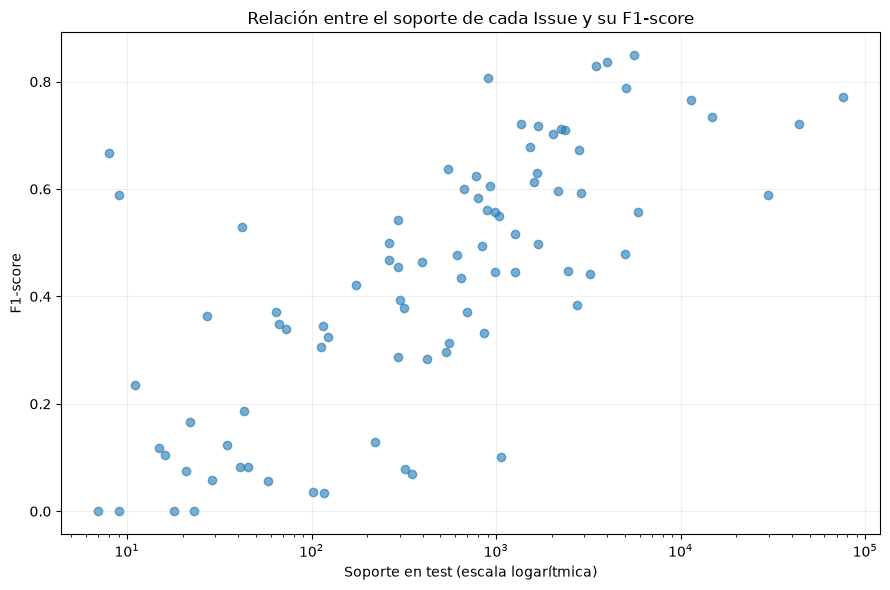

Figura guardada en: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\reports\figures\issue_soporte_vs_f1.png


In [51]:
plt.figure(figsize=(9, 6))
plt.scatter(clases_jer_df["support"], clases_jer_df["f1-score"], alpha=0.6)
plt.xscale("log")
plt.xlabel("Soporte en test (escala logarítmica)")
plt.ylabel("F1-score")
plt.title("Relación entre el soporte de cada Issue y su F1-score")
plt.grid(alpha=0.2)
plt.tight_layout()
ruta_fig = FIGURES_DIR / "issue_soporte_vs_f1.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_fig)

La figura muestra una tendencia general positiva entre el número de observaciones disponibles para cada `Issue` y su F1-score. Las categorías con menor soporte concentran una mayor proporción de valores de F1 reducidos o próximos a cero, mientras que las clases con cientos o miles de observaciones tienden a alcanzar un rendimiento superior.

Sin embargo, la relación no es determinista. Existen categorías con poco soporte que alcanzan resultados relativamente elevados y, al mismo tiempo, algunas clases con un volumen considerable de observaciones presentan un F1 moderado o bajo.

Esto indica que la disponibilidad de ejemplos es un factor relevante para el rendimiento del clasificador, pero no el único. La similitud semántica entre categorías, el desbalance existente dentro de cada `Product` y la propia dificultad de distinguir determinados tipos de reclamación también pueden influir en los resultados.

## 21. Errores de confusión más frecuentes

Una matriz completa sería difícil de leer con muchas categorías, por lo que se muestran los pares `Issue real → Issue predicho` más frecuentes.

In [52]:
errores = pd.DataFrame({
    "Product": test_df[COL_PRODUCT].values,
    "Issue real": test_df[COL_ISSUE].values,
    "Issue predicho": pred_jer
})
errores = errores[errores["Issue real"] != errores["Issue predicho"]]

errores_frecuentes = (
    errores.groupby(["Product", "Issue real", "Issue predicho"]).size()
           .rename("Errores").reset_index().sort_values("Errores", ascending=False)
)
display(errores_frecuentes.head(30))

,Product,Issue real,Issue predicho,Errores
216,Credit reporting or other personal consumer reports,Improper use of your report,Incorrect information on your report,10579
235,Credit reporting or other personal consumer reports,Problem with a company's investigation into an existing problem,Incorrect information on your report,10179
223,Credit reporting or other personal consumer reports,Incorrect information on your report,Improper use of your report,6907
225,Credit reporting or other personal consumer reports,Incorrect information on your report,Problem with a company's investigation into an existing problem,5548
234,Credit reporting or other personal consumer reports,Problem with a company's investigation into an existing problem,Improper use of your report,2984
218,Credit reporting or other personal consumer reports,Improper use of your report,Problem with a company's investigation into an existing problem,2051
268,Debt collection,False statements or representation,Attempts to collect debt not owed,1963
286,Debt collection,Written notification about debt,Attempts to collect debt not owed,1914
39,Checking or savings account,Problem with a lender or other company charging your account,Managing an account,1645
280,Debt collection,Took or threatened to take negative or legal action,Attempts to collect debt not owed,1168


El análisis de los pares de error muestra que las equivocaciones del modelo jerárquico no se distribuyen de forma aleatoria, sino que se concentran en determinados grupos de `Issue` pertenecientes al mismo `Product`.

Las confusiones más numerosas aparecen en `Credit reporting or other personal consumer reports`. Por ejemplo, `Improper use of your report` se clasifica como `Incorrect information on your report` en 10.579 observaciones, mientras que `Problem with a company's investigation into an existing problem` se confunde con esta misma categoría en 10.179 casos.

También se observan patrones de confusión dentro de `Debt collection`, especialmente entre categorías como `Attempts to collect debt not owed`, `False statements or representation` y `Written notification about debt`.

Estos resultados muestran que el bajo rendimiento de algunas categorías no depende únicamente de su frecuencia. Incluso entre clases con un elevado número de observaciones existen errores recurrentes, lo que sugiere que determinadas categorías presentan patrones textuales difíciles de separar mediante una representación TF-IDF y un clasificador lineal.

Por tanto, aunque la arquitectura jerárquica reduce el espacio de clasificación y mejora considerablemente el rendimiento respecto al modelo global, sigue existiendo ambigüedad entre determinados `Issue` dentro de un mismo `Product`.

## 22. Ejemplos reales de errores

In [53]:
resultado_test = test_df[[COL_TEXTO, COL_PRODUCT, COL_ISSUE]].copy()
resultado_test["Issue_predicho"] = pred_jer
resultado_test["Correcto"] = resultado_test[COL_ISSUE] == resultado_test["Issue_predicho"]

n_errores = (~resultado_test["Correcto"]).sum()
if n_errores > 0:
    display(resultado_test[~resultado_test["Correcto"]].sample(min(15, n_errores), random_state=RANDOM_STATE))
else:
    print("No se han producido errores en test.")

,Consumer complaint narrative,Product,Issue,Issue_predicho,Correcto
102303,immediate deletion of the account and {$1000.00} per violation of the FCRA as I am writing to address a matter of gr...,Student loan,Struggling to repay your loan,Dealing with your lender or servicer,False
79310,# # # Subject : FORMAL XXXX XXXX COMPLIANT DISPUTE DEMAND FOR DELETION OF INACCURATE COLLECTIONS Dear Compliance Dep...,Credit reporting or other personal consumer reports,Problem with a company's investigation into an existing problem,Improper use of your report,False
143565,This COMPLAINT serves as a formal follow-up to my previous complaint submitted last month regarding inaccurate and d...,Credit reporting or other personal consumer reports,Incorrect information on your report,Problem with a company's investigation into an existing problem,False
14551,"Re : Formal Debt Validation Request Account : TrueAccord [ XXXX ] Dear Sir/Madam, I am in receipt of your communicat...",Debt collection,Attempts to collect debt not owed,False statements or representation,False
253641,am the consumer reporting an abusive credit reporting and collection practice by LVNV Funding LLC. They filed a laws...,Debt collection,Took or threatened to take negative or legal action,Attempts to collect debt not owed,False
238584,I filed a CFPB complaint against Lexis Nexis and they aren't responding to the complaint but sending me stall emails...,Credit reporting or other personal consumer reports,Problem with a company's investigation into an existing issue,Problem with a company's investigation into an existing problem,False
93291,Company states i XXXX XXXX XXXX the co-signer on the original contract @ the time my credit score was very low and ...,Credit reporting or other personal consumer reports,Incorrect information on your report,Problem with a company's investigation into an existing problem,False
138125,"Sent letter on XXXX, they received by XXXX with return receipt, asking for validation of original alleged debt, all ...",Debt collection,Electronic communications,False statements or representation,False
71601,Payoff amount requested on XX/XX/XXXX via the companys website and then the request was confirmed the same day via p...,Mortgage,Closing on a mortgage,Trouble during payment process,False
51017,"XXXX of 2022, I paid off my credit card in full ( approx {$5000.00} ). Immediately after, the credit card company ( ...",Credit card,Closing your account,Incorrect information on your report,False


La inspección de una muestra de observaciones mal clasificadas permite complementar el análisis cuantitativo anterior. En varios casos, las narrativas contienen términos y situaciones que pueden estar relacionados con más de una categoría de `Issue` dentro del mismo `Product`.

Por ejemplo, en reclamaciones relacionadas con información crediticia pueden aparecer simultáneamente referencias a información incorrecta, disputas previas y procesos de investigación de la empresa. De forma similar, en las reclamaciones de cobro de deudas pueden coexistir referencias a intentos de cobro, comunicaciones, representaciones realizadas por la empresa o posibles acciones legales.

Esta superposición temática ayuda a explicar algunas de las confusiones observadas entre categorías. El modelo TF-IDF + LinearSVC se basa principalmente en patrones léxicos y no representa explícitamente relaciones semánticas complejas entre los distintos conceptos presentes en una narrativa.

El análisis cualitativo es, por tanto, consistente con los resultados anteriores: además del desbalance y del número de observaciones disponibles, la proximidad semántica entre determinados `Issue` constituye una fuente adicional de dificultad para la clasificación.

# Parte F — Guardado del modelo

## 23. Persistencia del modelo seleccionado

El criterio principal de selección es **F1 macro**, porque `Issue` es un problema multiclase desequilibrado. Se guarda el enfoque con mejor F1 macro.

Los `.pkl` deben mantenerse fuera de GitHub si `models/` está ignorado por `.gitignore`.

En el caso del enfoque jerárquico, el artefacto contiene un clasificador específico para cada `Product`, incluyendo su vectorizador TF-IDF y su modelo LinearSVC correspondiente. Esto permite reutilizar posteriormente la arquitectura sin necesidad de volver a entrenar los modelos.

In [55]:
if f1m_jer >= f1m_global:
    ruta_modelo = MODELS_DIR / "issue_hierarchical_svm.pkl"
    artefacto = {
        "tipo": "hierarchical",
        "modelos_por_producto": modelos_issue,
        "configuracion": {
            "min_combinacion": 20,
            "max_train_por_producto": MAX_TRAIN_POR_PRODUCTO,
            "max_features_producto": MAX_FEATURES_PRODUCTO,
            "random_state": RANDOM_STATE
        },
        "metricas_test": {
            "accuracy": float(a_jer),
            "f1_macro": float(f1m_jer),
            "f1_weighted": float(f1w_jer)
        }
    }
else:
    ruta_modelo = MODELS_DIR / "issue_global_svm.pkl"
    artefacto = {
        "tipo": "global",
        "vectorizador": tfidf_global,
        "modelo": svm_global,
        "configuracion": {
            "min_combinacion": MIN_COMBINACION,
            "n_train": N_TRAIN_GLOBAL,
            "random_state": RANDOM_STATE
        },
        "metricas_test": {
            "accuracy": float(a_global),
            "f1_macro": float(f1m_global),
            "f1_weighted": float(f1w_global)
        }
    }
joblib.dump(
    artefacto,
    ruta_modelo
)
print("Modelo seleccionado:", artefacto["tipo"])
print("Modelo guardado en:", ruta_modelo)
print(
    f"Tamaño: "
    f"{ruta_modelo.stat().st_size / (1024**2):.2f} MB"
)

Modelo seleccionado: hierarchical
Modelo guardado en: C:\Users\Usuario\Documents\UCM Master\TFM Ana Valeria\models\issue_hierarchical_svm.pkl
Tamaño: 41.38 MB


## Verificación de recarga

In [56]:
modelo_recargado = joblib.load(
    ruta_modelo
)
print("Artefacto recuperado correctamente.")
print("Tipo:", modelo_recargado["tipo"])
print(
    "F1 macro guardado:",
    round(
        modelo_recargado["metricas_test"]["f1_macro"],
        4
    )
)
if modelo_recargado["tipo"] == "hierarchical":
    print(
        "Modelos por Product:",
        len(modelo_recargado["modelos_por_producto"])
    )

Artefacto recuperado correctamente.
Tipo: hierarchical
F1 macro guardado: 0.4279
Modelos por Product: 11


## 24. Conclusiones

El análisis de `Issue` muestra un problema de clasificación más granular que `Product`, con un mayor número de categorías y una distribución desigual de observaciones. El estudio conjunto de ambas variables permite comprobar que existe una estructura jerárquica natural entre `Product` e `Issue`.

Para garantizar una evaluación estable se conservaron las combinaciones `Product-Issue` con un mínimo de **20 observaciones**. Este filtrado redujo el conjunto de 1.295.164 a **1.295.104 observaciones**, eliminando únicamente 60 registros y manteniendo aproximadamente el **100,00 %** del conjunto disponible. El conjunto final utilizado para el modelado contiene **86 categorías de Issue y 128 combinaciones Product-Issue**.

Se compararon dos estrategias sobre exactamente el mismo conjunto de test:

| Modelo | Accuracy | F1 macro | F1 weighted |
|---|---:|---:|---:|
| TF-IDF + Linear SVM global | 0,6160 | 0,2785 | 0,6025 |
| TF-IDF + Linear SVM jerárquico | **0,6920** | **0,4279** | **0,6830** |

El **modelo jerárquico** obtuvo el mayor F1 macro. La mejora absoluta respecto al modelo global fue de **0,1495 puntos**, lo que supone una mejora relativa de aproximadamente **53,7 %**. Esto respalda la hipótesis de que condicionar la predicción de `Issue` al `Product` reduce la complejidad del problema y permite que cada clasificador se especialice en un conjunto más reducido de categorías.

El análisis por producto mostró diferencias importantes en el rendimiento. `Prepaid card` obtuvo el mayor F1 macro (**0,5381**), seguido de `Debt collection` (**0,4934**) y `Credit card` (**0,4607**). Por el contrario, `Payday loan, title loan, personal loan, or advance loan` presentó el menor F1 macro (**0,2146**), seguido de `Student loan` (**0,2515**).

El análisis de errores mostró que las dificultades no se explican únicamente por la menor representación de determinadas clases. Aunque los `Issue` con poco soporte tienden a presentar un rendimiento inferior, también existen confusiones recurrentes entre categorías frecuentes y semánticamente próximas dentro de un mismo `Product`. Este comportamiento es especialmente visible en `Credit reporting or other personal consumer reports` y `Debt collection`.

Desde la perspectiva de **Mail Intelligence**, los resultados permiten plantear una arquitectura en dos niveles:

1. clasificación inicial del área o producto;
2. clasificación posterior del motivo o incidencia dentro de ese contexto.

La evaluación jerárquica de este notebook utiliza el `Product` real para aislar el rendimiento de `Issue`. Por tanto, estas métricas representan el rendimiento del segundo nivel cuando el primer nivel es correcto. La propagación de errores se evaluará posteriormente al integrar ambos niveles en el pipeline final.

### Decisión para el proyecto

- **Modelo seleccionado para `Issue`:** TF-IDF + LinearSVC jerárquico por `Product`.
- **Métrica principal:** F1 macro = **0,4279**.
- **Accuracy:** **0,6920**.
- **F1 weighted:** **0,6830**.
- **Artefacto generado:** `issue_hierarchical_svm.pkl`, que contiene los modelos y vectorizadores específicos de los 11 `Product`.
- **Próximo paso:** integrar la clasificación de `Product` e `Issue` en una función de inferencia reutilizable y posteriormente incorporarla a la aplicación.

# 25. Resumen técnico reproducible

In [57]:
cobertura_final = len(df_model) / len(df_issue_clean) * 100

print("=" * 70)
print("RESUMEN — MODELADO DE ISSUE")
print("=" * 70)

print(f"Dataset limpio inicial: {len(df_issue_clean):,}")
print(f"Dataset modelado:       {len(df_model):,}")
print(f"Cobertura:              {cobertura_final:.2f}%")
print(f"Nº Issues modelados:    {df_model[COL_ISSUE].nunique()}")
print(f"Nº combinaciones:       {df_model['Product_Issue'].nunique()}")

print("\nBASELINE GLOBAL")
print(f"Accuracy:    {a_global:.4f}")
print(f"F1 macro:    {f1m_global:.4f}")
print(f"F1 weighted: {f1w_global:.4f}")

print("\nMODELO JERÁRQUICO")
print(f"Accuracy:    {a_jer:.4f}")
print(f"F1 macro:    {f1m_jer:.4f}")
print(f"F1 weighted: {f1w_jer:.4f}")

print("\nSELECCIÓN")
print("Modelo con mayor F1 macro:", mejor_modelo)

print("=" * 70)

RESUMEN — MODELADO DE ISSUE
Dataset limpio inicial: 1,295,164
Dataset modelado:       1,295,104
Cobertura:              100.00%
Nº Issues modelados:    86
Nº combinaciones:       128

BASELINE GLOBAL
Accuracy:    0.6160
F1 macro:    0.2785
F1 weighted: 0.6025

MODELO JERÁRQUICO
Accuracy:    0.6920
F1 macro:    0.4279
F1 weighted: 0.6830

SELECCIÓN
Modelo con mayor F1 macro: jerárquico
